In [ ]:
import os
import rasterio
import numpy as np
from google.colab import drive
drive.mount('/content/drive')


dataset_path = '/content/drive/MyDrive/dataset'
covariables_path = '/content/drive/MyDrive/Covariables'


tif_files = [f for f in os.listdir(dataset_path) if f.endswith('.tif')]
print("Fichiers trouvés :", tif_files)

images = {}
for filename in tif_files:
    name = filename.replace('.tif', '')
    filepath = os.path.join(dataset_path, filename)

    with rasterio.open(filepath) as src:
        images[name] = src.read()
        print(f"{name} → shape: {images[name].shape}, dtype: {images[name].dtype}")


tif_files = [f for f in os.listdir(covariables_path) if f.endswith('.tif')]
print("Fichiers trouvés :", tif_files)

images = {}
for filename in tif_files:
    name = filename.replace('.tif', '')
    filepath = os.path.join(covariables_path, filename)

    with rasterio.open(filepath) as src:
        images[name] = src.read()
        print(f"{name} → shape: {images[name].shape}, dtype: {images[name].dtype}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fichiers trouvés : ['CDL_AR1.tif', 'CDL_CA1.tif', 'CDL_AR2.tif', 'CDL_CA2.tif', 'S2_AR2.tif', 'S2_AR1.tif', 'S2_CA1.tif', 'S2_CA2.tif']
CDL_AR1 → shape: (1, 563, 784), dtype: uint8
CDL_CA1 → shape: (1, 1131, 1076), dtype: uint8
CDL_AR2 → shape: (1, 853, 614), dtype: uint8
CDL_CA2 → shape: (1, 1127, 1090), dtype: uint8
S2_AR2 → shape: (360, 817, 706), dtype: float32
S2_AR1 → shape: (360, 521, 928), dtype: float32
S2_CA1 → shape: (360, 929, 1114), dtype: float32
S2_CA2 → shape: (360, 929, 1115), dtype: float32
Fichiers trouvés : ['soil_AR1.tif', 'topo_AR1.tif', 'soil_AR2.tif', 'topo_AR2.tif', 'climate_AR2.tif', 'soil_CA1.tif', 'climate_AR1.tif', 'topo_CA1.tif', 'soil_CA2.tif', 'topo_CA2.tif', 'climate_CA1.tif', 'climate_CA2.tif']
soil_AR1 → shape: (3, 520, 928), dtype: float32
topo_AR1 → shape: (2, 520, 928), dtype: float32
soil_AR2 → shape: (3, 818, 706), dtyp

In [ ]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling

def align_to_reference(src_path, ref_path):
    """Reprojette src sur la même grille que ref"""
    with rasterio.open(ref_path) as ref:
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_width = ref.width
        ref_height = ref.height
        ref_profile = ref.profile

    with rasterio.open(src_path) as src:
        data_aligned = np.zeros(
            (src.count, ref_height, ref_width),
            dtype=src.dtypes[0]
        )
        for i in range(src.count):
            reproject(
                source=rasterio.band(src, i+1),
                destination=data_aligned[i],
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.nearest
            )
    return data_aligned

# Aligner tout sur S2 pour chaque zone
zones = ['AR1', 'AR2', 'CA1', 'CA2']

aligned = {}
for z in zones:
    ref = f'/content/drive/MyDrive/dataset/S2_{z}.tif'

    aligned[f'cdl_{z}']     = align_to_reference(f'/content/drive/MyDrive/dataset/CDL_{z}.tif', ref)
    aligned[f'soil_{z}']    = align_to_reference(f'/content/drive/MyDrive/Covariables/soil_{z}.tif', ref)
    aligned[f'topo_{z}']    = align_to_reference(f'/content/drive/MyDrive/Covariables/topo_{z}.tif', ref)
    aligned[f'climate_{z}'] = align_to_reference(f'/content/drive/MyDrive/Covariables/climate_{z}.tif', ref)

    print(f"{z} → CDL: {aligned[f'cdl_{z}'].shape}, Soil: {aligned[f'soil_{z}'].shape}, Topo: {aligned[f'topo_{z}'].shape}, Climate: {aligned[f'climate_{z}'].shape}")

AR1 → CDL: (1, 521, 928), Soil: (3, 521, 928), Topo: (2, 521, 928), Climate: (108, 521, 928)
AR2 → CDL: (1, 817, 706), Soil: (3, 817, 706), Topo: (2, 817, 706), Climate: (108, 817, 706)
CA1 → CDL: (1, 929, 1114), Soil: (3, 929, 1114), Topo: (2, 929, 1114), Climate: (108, 929, 1114)
CA2 → CDL: (1, 929, 1115), Soil: (3, 929, 1115), Topo: (2, 929, 1115), Climate: (108, 929, 1115)


In [ ]:
import numpy as np

# ─────────────────────────────────────────────
# PARAMÈTRES EXACTS DU PAPIER (Table 2)
# ─────────────────────────────────────────────
TRAIN_PER_CLASS = 240
VAL_PER_CLASS   = 60
RANDOM_SEED     = 42

# Distribution EXACTE du papier (Table 2)
AR_DISTRIBUTION = {
    5:   4677,   # Soybeans
    3:   2423,   # Rice
    1:   1522,   # Corn
    2:    762,   # Cotton
    999:  616,   # Others
}

CA_DISTRIBUTION = {
    69:  2054,   # Grapes
    3:   2037,   # Rice
    36:   974,   # Alfalfa
    75:   783,   # Almonds
    204:  640,   # Pistachios
    999: 3512,   # Others
}

# Noms pour affichage
CLASS_NAMES_AR = {5:'Soybeans', 3:'Rice', 1:'Corn', 2:'Cotton', 999:'Others'}
CLASS_NAMES_CA = {69:'Grapes', 3:'Rice', 36:'Alfalfa', 75:'Almonds', 204:'Pistachios', 999:'Others'}

# Codes CDL named (tout ce qui n'est pas dans cette liste → Others)
NAMED_CODES_AR = {5, 1, 2, 3}
NAMED_CODES_CA = {69, 3, 36, 75, 204}

# ─────────────────────────────────────────────
# ÉTAPE 1 : collecter TOUS les pixels dispo
#           sur les 2 zones d'un état
# ─────────────────────────────────────────────
def collect_state_pixels(zones, aligned_dict, named_codes):
    """
    Collecte tous les pixels agricoles des 2 zones d'un état.
    Retourne dict: code → liste de (zone, row, col)
    """
    from collections import defaultdict
    pool = defaultdict(list)   # code → [(zone, row, col), ...]

    for zone in zones:
        cdl = aligned_dict[f'cdl_{zone}'][0]   # (H, W)
        rows, cols = np.where(cdl > 0)          # masque cropland
        labels = cdl[rows, cols]

        for r, c, lbl in zip(rows, cols, labels):
            code = int(lbl)
            if code in named_codes:
                pool[code].append((zone, r, c))
            else:
                pool[999].append((zone, r, c))  # Others

    # Afficher disponibilité
    print("  Pixels disponibles par classe :")
    for code, pts in sorted(pool.items()):
        print(f"    code {code:4d} : {len(pts):7d} pixels")

    return pool

# ─────────────────────────────────────────────
# ÉTAPE 2 : tirer exactement N pixels par classe
#           selon la distribution du papier
# ─────────────────────────────────────────────
def sample_state(zones, aligned_dict, named_codes, distribution, class_names,
                 seed=RANDOM_SEED):
    """
    Retourne samples dict: 'rows','cols','labels','zones' arrays
    avec exactement la distribution du papier.
    """
    rng = np.random.default_rng(seed)

    # Collecter pool
    pool = collect_state_pixels(zones, aligned_dict, named_codes)

    all_zones_out  = []
    all_rows_out   = []
    all_cols_out   = []
    all_labels_out = []

    print("\n  Échantillonnage :")
    for code, n_target in distribution.items():
        name = class_names.get(code, f'code_{code}')
        available = pool.get(code, [])

        if len(available) == 0:
            print(f"    ⚠ {name:12s}: AUCUN pixel disponible !")
            continue

        if len(available) < n_target:
            print(f"    ⚠ {name:12s}: seulement {len(available)} dispo "
                  f"(target={n_target}) → on prend tout")
            chosen = available
        else:
            idx = rng.choice(len(available), size=n_target, replace=False)
            chosen = [available[i] for i in idx]

        for (z, r, c) in chosen:
            all_zones_out.append(z)
            all_rows_out.append(r)
            all_cols_out.append(c)
            all_labels_out.append(code)

        print(f"    ✓ {name:12s}: {len(chosen):5d} / {n_target} samples")

    return {
        'zones':  np.array(all_zones_out),
        'rows':   np.array(all_rows_out),
        'cols':   np.array(all_cols_out),
        'labels': np.array(all_labels_out),
    }

# ─────────────────────────────────────────────
# ÉTAPE 3 : split stratifié Train/Val/Test
# ─────────────────────────────────────────────
def stratified_split(samples, seed=RANDOM_SEED):
    rng  = np.random.default_rng(seed)
    labels = samples['labels']

    train_idx, val_idx, test_idx = [], [], []

    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0].copy()
        rng.shuffle(idx)
        n = len(idx)

        # Garantir minimum train+val même si peu de samples
        tr = min(TRAIN_PER_CLASS, n)
        vl = min(VAL_PER_CLASS,   n - tr)

        train_idx.extend(idx[:tr])
        val_idx.extend(  idx[tr:tr+vl])
        test_idx.extend( idx[tr+vl:])

    def subset(idxs):
        i = np.array(idxs)
        return {k: samples[k][i] for k in samples}

    tr = subset(train_idx)
    vl = subset(val_idx)
    te = subset(test_idx)

    print(f"\n  Split → Train: {len(tr['labels'])} | "
          f"Val: {len(vl['labels'])} | "
          f"Test: {len(te['labels'])}")
    return tr, vl, te

# ─────────────────────────────────────────────
# LANCER
# ─────────────────────────────────────────────
print("=" * 55)
print("ARKANSAS  (AR1 + AR2  →  10 000 samples)")
print("=" * 55)
ar_samples = sample_state(
    zones        = ['AR1', 'AR2'],
    aligned_dict = aligned,
    named_codes  = NAMED_CODES_AR,
    distribution = AR_DISTRIBUTION,
    class_names  = CLASS_NAMES_AR,
)
ar_train, ar_val, ar_test = stratified_split(ar_samples)

print()
print("=" * 55)
print("CALIFORNIA  (CA1 + CA2  →  10 000 samples)")
print("=" * 55)
ca_samples = sample_state(
    zones        = ['CA1', 'CA2'],
    aligned_dict = aligned,
    named_codes  = NAMED_CODES_CA,
    distribution = CA_DISTRIBUTION,
    class_names  = CLASS_NAMES_CA,
)
ca_train, ca_val, ca_test = stratified_split(ca_samples)

# ─────────────────────────────────────────────
# VÉRIFICATION FINALE
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("VÉRIFICATION vs Table 2 du papier")
print("=" * 55)
for state, samp, dist, names in [
    ('Arkansas',   ar_samples, AR_DISTRIBUTION, CLASS_NAMES_AR),
    ('California', ca_samples, CA_DISTRIBUTION, CLASS_NAMES_CA),
]:
    print(f"\n{state}:")
    print(f"  {'Classe':12s}  {'Papier':>8}  {'Obtenu':>8}  {'OK?'}")
    print(f"  {'-'*40}")
    for code, n_paper in dist.items():
        n_got = int(np.sum(samp['labels'] == code))
        ok = '✓' if n_got == n_paper else f'⚠ diff={n_got - n_paper}'
        print(f"  {names[code]:12s}  {n_paper:>8}  {n_got:>8}  {ok}")
    print(f"  {'TOTAL':12s}  {sum(dist.values()):>8}  {len(samp['labels']):>8}")

ARKANSAS  (AR1 + AR2  →  10 000 samples)
  Pixels disponibles par classe :
    code    1 :  163670 pixels
    code    2 :  101119 pixels
    code    3 :   86478 pixels
    code    5 :  287750 pixels
    code  999 :   65736 pixels

  Échantillonnage :
    ✓ Soybeans    :  4677 / 4677 samples
    ✓ Rice        :  2423 / 2423 samples
    ✓ Corn        :  1522 / 1522 samples
    ✓ Cotton      :   762 / 762 samples
    ✓ Others      :   616 / 616 samples

  Split → Train: 1200 | Val: 300 | Test: 8500

CALIFORNIA  (CA1 + CA2  →  10 000 samples)
  Pixels disponibles par classe :
    code    3 :  183057 pixels
    code   36 :   11960 pixels
    code   69 :  171349 pixels
    code   75 :   70271 pixels
    code  204 :   27030 pixels
    code  999 :  345398 pixels

  Échantillonnage :
    ✓ Grapes      :  2054 / 2054 samples
    ✓ Rice        :  2037 / 2037 samples
    ✓ Alfalfa     :   974 / 974 samples
    ✓ Almonds     :   783 / 783 samples
    ✓ Pistachios  :   640 / 640 samples
    ✓ Others

In [ ]:
import numpy as np

# ─────────────────────────────────────────────
# EXTRACTION S2 + SAUVEGARDE .npy
# ─────────────────────────────────────────────
# S2 shape : (360, H, W) = 36 dates × 10 bandes → reshape en (36, 10, H, W)

def extract_s2_features(samples, aligned_dict, save_path_prefix):
    """
    Pour chaque pixel (zone, row, col) → extrait S2 (36, 10)
    Sauvegarde :
        {prefix}_X.npy  → (N, 36, 10)  features S2
        {prefix}_y.npy  → (N,)          labels
        {prefix}_meta.npy → zones+coords pour debug
    """
    N = len(samples['labels'])
    X = np.zeros((N, 36, 10), dtype=np.float32)
    y = samples['labels'].astype(np.int16)

    # Cache S2 par zone pour ne pas relire à chaque pixel
    s2_cache = {}

    print(f"  Extraction de {N} pixels...")

    for i, (zone, row, col) in enumerate(zip(
            samples['zones'], samples['rows'], samples['cols'])):

        # Charger S2 en cache si pas encore fait
        if zone not in s2_cache:
            s2_raw = aligned_dict[f's2_{zone}']   # (360, H, W)
            # Reshape : (360, H, W) → (36, 10, H, W)
            s2_cache[zone] = s2_raw.reshape(36, 10,
                                             s2_raw.shape[1],
                                             s2_raw.shape[2])
            print(f"    S2 {zone} chargé → {s2_cache[zone].shape}")

        # Extraire le pixel : (36, 10, H, W) → (36, 10)
        X[i] = s2_cache[zone][:, :, row, col]   # (36, 10)

        if (i + 1) % 2000 == 0:
            print(f"    {i+1}/{N} pixels extraits...")

    # Sauvegarder
    np.save(f'{save_path_prefix}_X.npy', X)
    np.save(f'{save_path_prefix}_y.npy', y)
    print(f"  ✓ Sauvegardé : {save_path_prefix}_X.npy  → {X.shape}")
    print(f"  ✓ Sauvegardé : {save_path_prefix}_y.npy  → {y.shape}")

    # Stats rapides
    print(f"  Stats X : min={X.min():.4f}, max={X.max():.4f}, "
          f"NaN={np.isnan(X).sum()}, zeros={np.sum(X==0)}")
    return X, y


# ─────────────────────────────────────────────
# S2 est dans aligned sous clé 's2_AR1' etc.
# Si pas encore dans aligned, on les charge ici
# ─────────────────────────────────────────────
zones_all = ['AR1', 'AR2', 'CA1', 'CA2']
for z in zones_all:
    key = f's2_{z}'
    if key not in aligned:
        path = f'/content/drive/MyDrive/dataset/S2_{z}.tif'
        with rasterio.open(path) as src:
            aligned[key] = src.read()   # (360, H, W)
        print(f"S2 {z} chargé → {aligned[key].shape}")

# ─────────────────────────────────────────────
# EXTRACTION PAR ÉTAT
# ─────────────────────────────────────────────
save_dir = '/content/drive/MyDrive/dataset'

# ── ARKANSAS ──
print("\n" + "="*50)
print("ARKANSAS  →  (10000, 36, 10)")
print("="*50)
AR_X, AR_y = extract_s2_features(
    samples      = ar_samples,
    aligned_dict = aligned,
    save_path_prefix = f'{save_dir}/AR'
)

# ── CALIFORNIA ──
print("\n" + "="*50)
print("CALIFORNIA  →  (10000, 36, 10)")
print("="*50)
CA_X, CA_y = extract_s2_features(
    samples      = ca_samples,
    aligned_dict = aligned,
    save_path_prefix = f'{save_dir}/CA'
)

# ─────────────────────────────────────────────
# VÉRIFICATION FINALE
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("VÉRIFICATION SHAPES")
print("="*50)
for state, X, y in [('Arkansas', AR_X, AR_y), ('California', CA_X, CA_y)]:
    print(f"\n{state}:")
    print(f"  X : {X.shape}  ← attendu (10000, 36, 10)")
    print(f"  y : {y.shape}  ← attendu (10000,)")
    print(f"  Classes : {np.unique(y, return_counts=True)}")
    assert X.shape == (10000, 36, 10), f"❌ Shape X incorrect !"
    assert y.shape == (10000,),        f"❌ Shape y incorrect !"
    print(f"  ✓ Shape correct")

print("\n✅ Fichiers sauvegardés :")
print(f"   {save_dir}/AR_X.npy  (10000, 36, 10)")
print(f"   {save_dir}/AR_y.npy  (10000,)")
print(f"   {save_dir}/CA_X.npy  (10000, 36, 10)")
print(f"   {save_dir}/CA_y.npy  (10000,)")

S2 AR1 chargé → (360, 521, 928)
S2 AR2 chargé → (360, 817, 706)
S2 CA1 chargé → (360, 929, 1114)
S2 CA2 chargé → (360, 929, 1115)

ARKANSAS  →  (10000, 36, 10)
  Extraction de 10000 pixels...
    S2 AR2 chargé → (36, 10, 817, 706)
    S2 AR1 chargé → (36, 10, 521, 928)
    2000/10000 pixels extraits...
    4000/10000 pixels extraits...
    6000/10000 pixels extraits...
    8000/10000 pixels extraits...
    10000/10000 pixels extraits...
  ✓ Sauvegardé : /content/drive/MyDrive/dataset/AR_X.npy  → (10000, 36, 10)
  ✓ Sauvegardé : /content/drive/MyDrive/dataset/AR_y.npy  → (10000,)
  Stats X : min=0.0000, max=15037.5000, NaN=0, zeros=749712

CALIFORNIA  →  (10000, 36, 10)
  Extraction de 10000 pixels...
    S2 CA2 chargé → (36, 10, 929, 1115)
    2000/10000 pixels extraits...
    S2 CA1 chargé → (36, 10, 929, 1114)
    4000/10000 pixels extraits...
    6000/10000 pixels extraits...
    8000/10000 pixels extraits...
    10000/10000 pixels extraits...
  ✓ Sauvegardé : /content/drive/MyDrive

In [ ]:
import numpy as np

# ─────────────────────────────────────────────
# EXTRACTION COVARIABLES (mêmes pixels que S2)
# ─────────────────────────────────────────────

def extract_covariables(samples, aligned_dict, save_path_prefix):
    """
    Extrait climate(36,3), soil(3), topo(2) pour les mêmes pixels que S2.
    Sauvegarde :
        {prefix}_climate.npy  → (N, 36, 3)
        {prefix}_soil.npy     → (N, 3)
        {prefix}_topo.npy     → (N, 2)
    """
    N = len(samples['labels'])

    climate_out = np.zeros((N, 36, 3),  dtype=np.float32)
    soil_out    = np.zeros((N, 3),      dtype=np.float32)
    topo_out    = np.zeros((N, 2),      dtype=np.float32)

    # Cache par zone
    cov_cache = {}

    print(f"  Extraction covariables pour {N} pixels...")

    for i, (zone, row, col) in enumerate(zip(
            samples['zones'], samples['rows'], samples['cols'])):

        # ── Charger et mettre en cache ──
        if zone not in cov_cache:
            # Climate : (108, H, W) → (36, 3, H, W)
            clim_raw = aligned_dict[f'climate_{zone}']   # (108, H, W)
            clim = clim_raw.reshape(36, 3,
                                    clim_raw.shape[1],
                                    clim_raw.shape[2])   # (36, 3, H, W)

            soil = aligned_dict[f'soil_{zone}']           # (3, H, W)
            topo = aligned_dict[f'topo_{zone}']           # (2, H, W)

            cov_cache[zone] = {
                'climate': clim,
                'soil':    soil,
                'topo':    topo,
            }
            print(f"    Covariables {zone} chargées → "
                  f"climate{clim.shape}, soil{soil.shape}, topo{topo.shape}")

        c = cov_cache[zone]

        # ── Extraire le pixel ──
        climate_out[i] = c['climate'][:, :, row, col]   # (36, 3)
        soil_out[i]    = c['soil'][:,    row, col]       # (3,)
        topo_out[i]    = c['topo'][:,    row, col]       # (2,)

        if (i + 1) % 2000 == 0:
            print(f"    {i+1}/{N} pixels extraits...")

    # ── Sauvegarder ──
    np.save(f'{save_path_prefix}_climate.npy', climate_out)
    np.save(f'{save_path_prefix}_soil.npy',    soil_out)
    np.save(f'{save_path_prefix}_topo.npy',    topo_out)

    print(f"\n  ✓ {save_path_prefix}_climate.npy → {climate_out.shape}")
    print(f"  ✓ {save_path_prefix}_soil.npy    → {soil_out.shape}")
    print(f"  ✓ {save_path_prefix}_topo.npy    → {topo_out.shape}")

    # Stats NaN
    for name, arr in [('climate', climate_out),
                      ('soil',    soil_out),
                      ('topo',    topo_out)]:
        nan_count = np.isnan(arr).sum()
        zero_count = np.sum(arr == 0)
        print(f"  Stats {name:8s}: min={arr.min():.4f}, "
              f"max={arr.max():.4f}, NaN={nan_count}, zeros={zero_count}")

    return climate_out, soil_out, topo_out


# ─────────────────────────────────────────────
# LANCER SUR LES 2 ÉTATS
# ─────────────────────────────────────────────
save_dir = '/content/drive/MyDrive/dataset'

print("=" * 55)
print("ARKANSAS — Extraction covariables")
print("=" * 55)
AR_climate, AR_soil, AR_topo = extract_covariables(
    samples          = ar_samples,
    aligned_dict     = aligned,
    save_path_prefix = f'{save_dir}/AR'
)

print()
print("=" * 55)
print("CALIFORNIA — Extraction covariables")
print("=" * 55)
CA_climate, CA_soil, CA_topo = extract_covariables(
    samples          = ca_samples,
    aligned_dict     = aligned,
    save_path_prefix = f'{save_dir}/CA'
)

# ─────────────────────────────────────────────
# VÉRIFICATION FINALE
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("VÉRIFICATION SHAPES")
print("=" * 55)

expected = {
    'climate': (10000, 36, 3),
    'soil':    (10000, 3),
    'topo':    (10000, 2),
}

for state, climate, soil, topo in [
    ('Arkansas',   AR_climate, AR_soil, AR_topo),
    ('California', CA_climate, CA_soil, CA_topo),
]:
    print(f"\n{state}:")
    for name, arr, exp in [
        ('climate', climate, expected['climate']),
        ('soil',    soil,    expected['soil']),
        ('topo',    topo,    expected['topo']),
    ]:
        ok = '✓' if arr.shape == exp else f'❌ attendu {exp}'
        print(f"  {name:8s} : {str(arr.shape):20s} {ok}")

print("\n✅ Fichiers sauvegardés :")
for state in ['AR', 'CA']:
    for cov in ['climate', 'soil', 'topo']:
        print(f"   {save_dir}/{state}_{cov}.npy")

ARKANSAS — Extraction covariables
  Extraction covariables pour 10000 pixels...
    Covariables AR2 chargées → climate(36, 3, 817, 706), soil(3, 817, 706), topo(2, 817, 706)
    Covariables AR1 chargées → climate(36, 3, 521, 928), soil(3, 521, 928), topo(2, 521, 928)
    2000/10000 pixels extraits...
    4000/10000 pixels extraits...
    6000/10000 pixels extraits...
    8000/10000 pixels extraits...
    10000/10000 pixels extraits...

  ✓ /content/drive/MyDrive/dataset/AR_climate.npy → (10000, 36, 3)
  ✓ /content/drive/MyDrive/dataset/AR_soil.npy    → (10000, 3)
  ✓ /content/drive/MyDrive/dataset/AR_topo.npy    → (10000, 2)
  Stats climate : min=0.0000, max=301.8078, NaN=0, zeros=0
  Stats soil    : min=nan, max=nan, NaN=141, zeros=15
  Stats topo    : min=0.0000, max=115.0000, NaN=0, zeros=10

CALIFORNIA — Extraction covariables
  Extraction covariables pour 10000 pixels...
    Covariables CA2 chargées → climate(36, 3, 929, 1115), soil(3, 929, 1115), topo(2, 929, 1115)
    2000/10000

In [ ]:
# ─────────────────────────────────────────────
# CHARGER AVEC allow_pickle=True (labels = strings)
# ─────────────────────────────────────────────
save_dir = '/content/drive/MyDrive/dataset'

AR_X = np.load(f'{save_dir}/pixels_arkansas.npy')
AR_y = np.load(f'{save_dir}/labels_arkansas.npy',  allow_pickle=True)
CA_X = np.load(f'{save_dir}/pixels_california.npy')
CA_y = np.load(f'{save_dir}/labels_california.npy', allow_pickle=True)

print(f"AR_X : {AR_X.shape}  AR_y : {AR_y.shape}  dtype: {AR_y.dtype}")
print(f"CA_X : {CA_X.shape}  CA_y : {CA_y.shape}  dtype: {CA_y.dtype}")
print(f"Classes AR : {np.unique(AR_y)}")
print(f"Classes CA : {np.unique(CA_y)}")

AR_X : (10000, 36, 10)  AR_y : (10000,)  dtype: object
CA_X : (10000, 36, 10)  CA_y : (10000,)  dtype: object
Classes AR : ['Corn' 'Cotton' 'Others' 'Rice' 'Soybeans']
Classes CA : ['Alfalfa' 'Almonds' 'Grapes' 'Others' 'Pistachios' 'Rice']


/tmp/ipykernel_12089/1295582746.py:16: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(ndvi_class, axis=0)   # (36,)


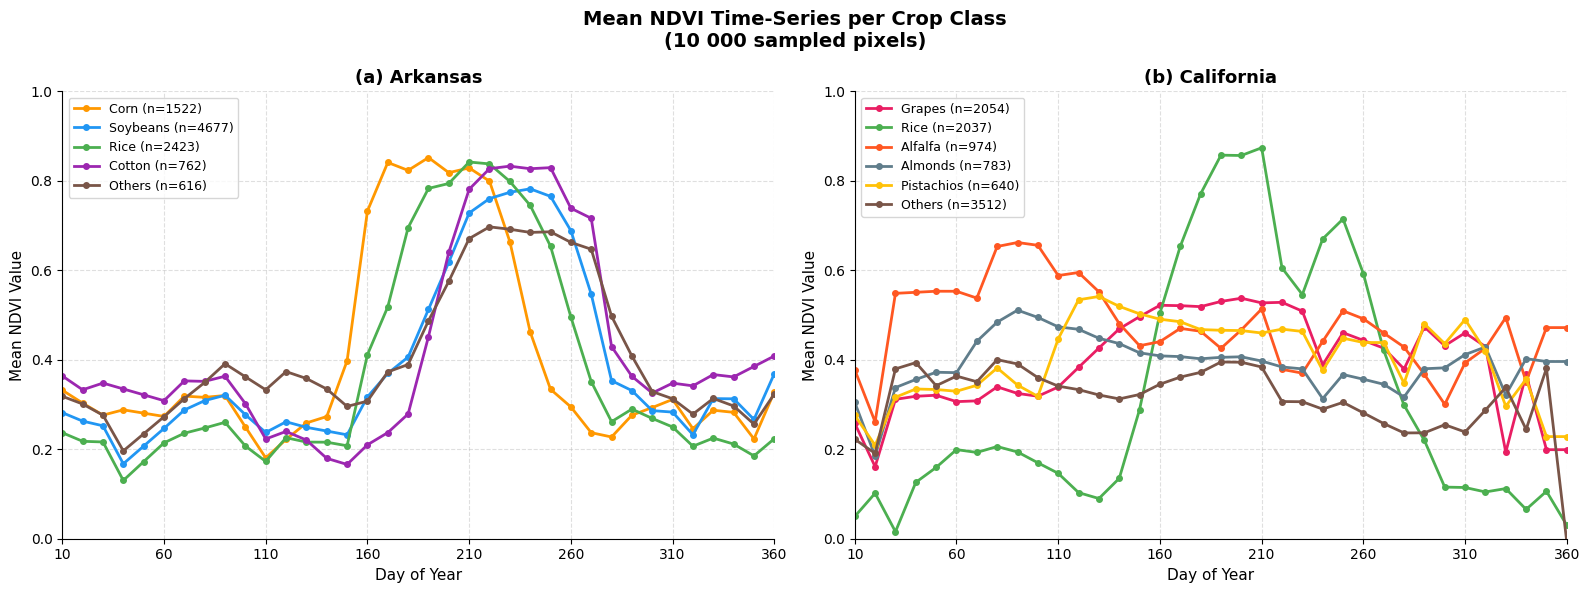

In [ ]:
from scipy.interpolate import interp1d

def compute_ndvi(X):
    red = X[:, :, 2].astype(float)
    nir = X[:, :, 6].astype(float)
    ndvi = (nir - red) / (nir + red + 1e-8)
    # zéros = missing → NaN
    ndvi[(red == 0) & (nir == 0)] = np.nan
    return ndvi

def mean_ndvi_interpolated(ndvi_class):
    """
    Calcule la moyenne par date, puis interpole les NaN
    pour que la courbe soit continue.
    """
    mean = np.nanmean(ndvi_class, axis=0)   # (36,)

    nan_mask = np.isnan(mean)
    if nan_mask.all():
        return mean   # tout NaN → rien à faire

    if nan_mask.any():
        x_ok  = np.where(~nan_mask)[0]
        y_ok  = mean[~nan_mask]
        f     = interp1d(x_ok, y_ok, kind='linear',
                         bounds_error=False,
                         fill_value=(y_ok[0], y_ok[-1]))
        mean[nan_mask] = f(np.where(nan_mask)[0])

    return mean

# ─────────────────────────────────────────────
AR_ndvi = compute_ndvi(AR_X)
CA_ndvi = compute_ndvi(CA_X)
doy = np.arange(1, 37) * 10

CLASS_INFO_AR = {
    1: ('Corn',     '#FF9800'),
    2: ('Soybeans', '#2196F3'),
    3: ('Rice',     '#4CAF50'),
    4: ('Cotton',   '#9C27B0'),
    0: ('Others',   '#795548'),
}
CLASS_INFO_CA = {
    1: ('Grapes',     '#E91E63'),
    2: ('Rice',       '#4CAF50'),
    3: ('Alfalfa',    '#FF5722'),
    4: ('Almonds',    '#607D8B'),
    5: ('Pistachios', '#FFC107'),
    0: ('Others',     '#795548'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NDVI)',
             fontsize=14, fontweight='bold')

for ax, ndvi, y, class_info, title in [
    (axes[0], AR_ndvi, AR_y, CLASS_INFO_AR, '(a) Arkansas'),
    (axes[1], CA_ndvi, CA_y, CLASS_INFO_CA, '(b) California'),
]:
    for code, (name, color) in class_info.items():
        mask = (y == code)
        if mask.sum() == 0:
            continue

        # ── Moyenne interpolée → courbe continue ──
        mean_ndvi = mean_ndvi_interpolated(ndvi[mask])

        ax.plot(doy, mean_ndvi,
                label=f'{name} (n={mask.sum()})',
                color=color, linewidth=2,
                marker='o', markersize=4,
                linestyle='-')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of Year', fontsize=11)
    ax.set_ylabel('Mean NDVI Value', fontsize=11)
    ax.set_xlim(10, 360)
    ax.set_ylim(0, 1)
    ax.set_xticks([10, 60, 110, 160, 210, 260, 310, 360])
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{save_dir}/ndvi_simple.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# VÉRIFICATION DES VALEURS MANQUANTES (= 0)
# ─────────────────────────────────────────────

for state, X, y, class_info in [
    ('Arkansas',   AR_X, AR_y, CLASS_INFO_AR),
    ('California', CA_X, CA_y, CLASS_INFO_CA),
]:
    print(f"\n{'='*55}")
    print(f"{state}  — X shape: {X.shape}")
    print(f"{'='*55}")

    # ── 1. Global ──
    total_vals  = X.size
    zero_vals   = np.sum(X == 0)
    zero_pixels = np.sum(np.all(X == 0, axis=(1, 2)))  # pixels entièrement nuls
    zero_dates  = np.sum(np.all(X == 0, axis=(0, 2)))  # dates entièrement nulles

    print(f"\n  Global:")
    print(f"    Total valeurs      : {total_vals:>10,}")
    print(f"    Zéros              : {zero_vals:>10,}  ({100*zero_vals/total_vals:.2f}%)")
    print(f"    Pixels tout-zéro   : {zero_pixels:>10,}  / {X.shape[0]}")
    print(f"    Dates tout-zéro    : {zero_dates:>10,}  / 36")

    # ── 2. Taux de missing par date (sur toutes bandes) ──
    # Une date est "manquante" pour un pixel si toutes les bandes = 0
    missing_per_date = np.sum(
        np.all(X == 0, axis=2),   # (10000, 36) → True si toutes bandes=0
        axis=0                     # (36,) → nb pixels manquants par date
    )
    doy = np.arange(1, 37) * 10
    print(f"\n  Taux missing par date (% pixels) :")
    for d, m in zip(doy, missing_per_date):
        bar = '█' * int(m / X.shape[0] * 30)
        print(f"    DOY {d:3d} : {m:5d} pixels manquants "
              f"({100*m/X.shape[0]:5.1f}%)  {bar}")

    # ── 3. Par classe ──
    print(f"\n  Taux missing par classe :")
    print(f"    {'Classe':12s}  {'N':>6}  {'Zéros':>8}  {'%Missing':>9}")
    print(f"    {'-'*42}")
    for code, (name, _) in class_info.items():
        mask = (y == code)
        if mask.sum() == 0:
            continue
        X_cls   = X[mask]                          # (N_cls, 36, 10)
        n_zeros = np.sum(X_cls == 0)
        n_total = X_cls.size
        # Dates manquantes = toutes bandes = 0
        missing_dates = np.sum(np.all(X_cls == 0, axis=2))  # (N_cls, 36)
        total_dates   = X_cls.shape[0] * 36
        print(f"    {name:12s}  {mask.sum():>6}  "
              f"{missing_dates:>8,}  {100*missing_dates/total_dates:>8.1f}%")

    # ── 4. Distribution du nombre de dates manquantes par pixel ──
    missing_dates_per_pixel = np.sum(
        np.all(X == 0, axis=2), axis=1   # (10000,)
    )
    print(f"\n  Distribution dates manquantes par pixel :")
    for n_miss in range(0, 37, 4):
        n_pix = np.sum(
            (missing_dates_per_pixel >= n_miss) &
            (missing_dates_per_pixel <  n_miss + 4)
        )
        bar = '█' * int(n_pix / X.shape[0] * 40)
        print(f"    {n_miss:2d}-{n_miss+3:2d} dates manquantes : "
              f"{n_pix:5d} pixels  {bar}")

    print(f"\n  Pixels SANS aucune valeur manquante : "
          f"{np.sum(missing_dates_per_pixel == 0):,} "
          f"/ {X.shape[0]:,} "
          f"({100*np.mean(missing_dates_per_pixel == 0):.1f}%)")


Arkansas  — X shape: (10000, 36, 10)

  Global:
    Total valeurs      :  3,600,000
    Zéros              :    748,828  (20.80%)
    Pixels tout-zéro   :        170  / 10000
    Dates tout-zéro    :          1  / 36

  Taux missing par date (% pixels) :
    DOY  10 :   173 pixels manquants (  1.7%)  
    DOY  20 :   170 pixels manquants (  1.7%)  
    DOY  30 :  5758 pixels manquants ( 57.6%)  █████████████████
    DOY  40 :  9969 pixels manquants ( 99.7%)  █████████████████████████████
    DOY  50 : 10000 pixels manquants (100.0%)  ██████████████████████████████
    DOY  60 :  1232 pixels manquants ( 12.3%)  ███
    DOY  70 :   173 pixels manquants (  1.7%)  
    DOY  80 :  1927 pixels manquants ( 19.3%)  █████
    DOY  90 :   263 pixels manquants (  2.6%)  
    DOY 100 :   909 pixels manquants (  9.1%)  ██
    DOY 110 :   171 pixels manquants (  1.7%)  
    DOY 120 :  1127 pixels manquants ( 11.3%)  ███
    DOY 130 :  1712 pixels manquants ( 17.1%)  █████
    DOY 140 :  3839 pixels